<a href="https://colab.research.google.com/github/UNIST-brAIns/2022-Spring/blob/main/Kaggle/Week2/brAIns_Kaggle_Week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from pandas import Series
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn')
sns.set(font_scale=2.5) # 이 두줄은 본 필자가 항상 쓰는 방법입니다. matplotlib 의 기본 scheme 말고 seaborn scheme 을 세팅하고, 일일이 graph 의 font size 를 지정할 필요 없이 seaborn 의 font_scale 을 사용하면 편합니다.
import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.tools as tls

#ignore warnings
import warnings
warnings.filterwarnings('ignore')



%matplotlib inline

from google.colab import drive
drive.mount('/content/drive') #force_remount=True
data_dir = '/content/drive/My Drive/Colab Notebooks/brAIns_Kaggle/data/titanic/'
df_train = pd.read_csv(data_dir+'train.csv')
df_test = pd.read_csv(data_dir+'test.csv')
df_train['FamilySize'] = df_train['SibSp'] + df_train['Parch'] + 1 # 자신을 포함해야하니 1을 더합니다
df_test['FamilySize'] = df_test['SibSp'] + df_test['Parch'] + 1 # 자신을 포함해야하니 1을 더합니다

df_test.loc[df_test.Fare.isnull(), 'Fare'] = df_test['Fare'].mean()

df_train['Fare'] = df_train['Fare'].map(lambda i: np.log(i) if i > 0 else 0)
df_test['Fare'] = df_test['Fare'].map(lambda i: np.log(i) if i > 0 else 0)

Mounted at /content/drive


# 3.1 Fill Null

## 3.1.1 Fill Null in Age using title

In [2]:
df_train['Initial']= df_train.Name.str.extract('([A-Za-z]+)\.') #lets extract the Salutations 정규식을 이용해 Salutation을 추출 .을 기준으로 끊음
    
df_test['Initial']= df_test.Name.str.extract('([A-Za-z]+)\.') #lets extract the Salutations

In [3]:
pd.crosstab(df_train['Initial'], df_train['Sex']).T.style.background_gradient(cmap='summer_r') #Checking the Initials with the Sex

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


In [4]:
df_train['Initial'].replace(['Mlle','Mme','Ms','Dr','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don', 'Dona'],
                        ['Miss','Miss','Miss','Mr','Mr','Mrs','Mrs','Other','Other','Other','Mr','Mr','Mr', 'Mr'],inplace=True) # 다양한 종류의 Salutation들이 있었는데 이를 5종류로 줄임

df_test['Initial'].replace(['Mlle','Mme','Ms','Dr','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don', 'Dona'],
                        ['Miss','Miss','Miss','Mr','Mr','Mrs','Mrs','Other','Other','Other','Mr','Mr','Mr', 'Mr'],inplace=True) # trainset에서도 반복함.

In [5]:
df_train.groupby('Initial').mean() # 각 그룹별 평균을 구해봄

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
Initial,,,,,,,,
Master,414.975000,0.575000,2.625000,4.574167,2.300000,1.375000,3.340710,4.675000
Miss,411.741935,0.704301,2.284946,21.860000,0.698925,0.537634,3.123713,2.236559
Mr,455.880907,0.162571,2.381853,32.739609,0.293006,0.151229,2.651507,1.444234
Mrs,456.393701,0.795276,1.984252,35.981818,0.692913,0.818898,3.443751,2.511811
Other,564.444444,0.111111,1.666667,45.888889,0.111111,0.111111,2.641605,1.222222


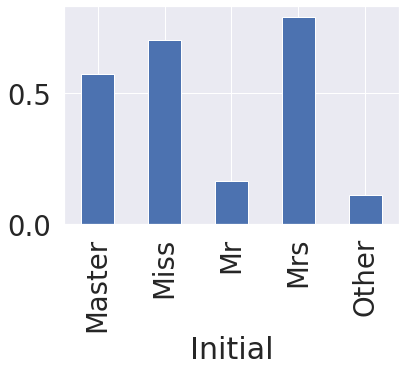

In [6]:
df_train.groupby('Initial')['Survived'].mean().plot.bar() # 각 그룹별 생존률을 그래프로 그림

In [7]:
df_train.groupby('Initial').mean()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
Initial,,,,,,,,
Master,414.975000,0.575000,2.625000,4.574167,2.300000,1.375000,3.340710,4.675000
Miss,411.741935,0.704301,2.284946,21.860000,0.698925,0.537634,3.123713,2.236559
Mr,455.880907,0.162571,2.381853,32.739609,0.293006,0.151229,2.651507,1.444234
Mrs,456.393701,0.795276,1.984252,35.981818,0.692913,0.818898,3.443751,2.511811
Other,564.444444,0.111111,1.666667,45.888889,0.111111,0.111111,2.641605,1.222222


In [8]:
df_train.loc[(df_train.Age.isnull())&(df_train.Initial=='Mr'),'Age'] = 33  # 각 그룹(Age)의 나이 데이터가 null 이면 이들을 그룹의 평균 나이로 채워줌
df_train.loc[(df_train.Age.isnull())&(df_train.Initial=='Mrs'),'Age'] = 36
df_train.loc[(df_train.Age.isnull())&(df_train.Initial=='Master'),'Age'] = 5
df_train.loc[(df_train.Age.isnull())&(df_train.Initial=='Miss'),'Age'] = 22
df_train.loc[(df_train.Age.isnull())&(df_train.Initial=='Other'),'Age'] = 46

df_test.loc[(df_test.Age.isnull())&(df_test.Initial=='Mr'),'Age'] = 33
df_test.loc[(df_test.Age.isnull())&(df_test.Initial=='Mrs'),'Age'] = 36
df_test.loc[(df_test.Age.isnull())&(df_test.Initial=='Master'),'Age'] = 5
df_test.loc[(df_test.Age.isnull())&(df_test.Initial=='Miss'),'Age'] = 22
df_test.loc[(df_test.Age.isnull())&(df_test.Initial=='Other'),'Age'] = 46

### 3.1.2 Fill Null in Embarked

In [9]:
print('Embarked has ', sum(df_train['Embarked'].isnull()), ' Null values')  # 탑승지에도 null data가 있었으므로, 이들이 몇갠지 확인

Embarked has  2  Null values


In [10]:
df_train['Embarked'].fillna('S', inplace=True) # 가장 많은 S로 채움

## 3.2 Change Age(continuous to categorical)

In [11]:
df_train['Age_cat'] = 0 # Continuous 한 Age 데이터를 Categorical feature 로 변형하는 과정, 각 카테고리는 10살을 기준으로 자름
df_train.loc[df_train['Age'] < 10, 'Age_cat'] = 0
df_train.loc[(10 <= df_train['Age']) & (df_train['Age'] < 20), 'Age_cat'] = 1
df_train.loc[(20 <= df_train['Age']) & (df_train['Age'] < 30), 'Age_cat'] = 2
df_train.loc[(30 <= df_train['Age']) & (df_train['Age'] < 40), 'Age_cat'] = 3
df_train.loc[(40 <= df_train['Age']) & (df_train['Age'] < 50), 'Age_cat'] = 4
df_train.loc[(50 <= df_train['Age']) & (df_train['Age'] < 60), 'Age_cat'] = 5
df_train.loc[(60 <= df_train['Age']) & (df_train['Age'] < 70), 'Age_cat'] = 6
df_train.loc[70 <= df_train['Age'], 'Age_cat'] = 7

df_test['Age_cat'] = 0
df_test.loc[df_test['Age'] < 10, 'Age_cat'] = 0
df_test.loc[(10 <= df_test['Age']) & (df_test['Age'] < 20), 'Age_cat'] = 1
df_test.loc[(20 <= df_test['Age']) & (df_test['Age'] < 30), 'Age_cat'] = 2
df_test.loc[(30 <= df_test['Age']) & (df_test['Age'] < 40), 'Age_cat'] = 3
df_test.loc[(40 <= df_test['Age']) & (df_test['Age'] < 50), 'Age_cat'] = 4
df_test.loc[(50 <= df_test['Age']) & (df_test['Age'] < 60), 'Age_cat'] = 5
df_test.loc[(60 <= df_test['Age']) & (df_test['Age'] < 70), 'Age_cat'] = 6
df_test.loc[70 <= df_test['Age'], 'Age_cat'] = 7

In [12]:
def category_age(x): # 위의 과정과 같은 과정이지만 apply method를 이용해 진행함
    if x < 10:
        return 0
    elif x < 20:
        return 1
    elif x < 30:
        return 2
    elif x < 40:
        return 3
    elif x < 50:
        return 4
    elif x < 60:
        return 5
    elif x < 70:
        return 6
    else:
        return 7    
    
df_train['Age_cat_2'] = df_train['Age'].apply(category_age)

In [13]:
print('1번 방법, 2번 방법 둘다 같은 결과를 내면 True 줘야함 -> ', (df_train['Age_cat'] == df_train['Age_cat_2']).all()) #두 가지 방법으로 진행한 결과가 같음을 알 수 있음.

1번 방법, 2번 방법 둘다 같은 결과를 내면 True 줘야함 ->  True


In [14]:
df_train.drop(['Age', 'Age_cat_2'], axis=1, inplace=True) # Age_cat 말고 다른 column 들을 날림
df_test.drop(['Age'], axis=1, inplace=True) 

## 3.3 Change Initial, Embarked and Sex (string to numerical)

In [15]:
df_train['Initial'] = df_train['Initial'].map({'Master': 0, 'Miss': 1, 'Mr': 2, 'Mrs': 3, 'Other': 4}) # name에서 가져온 initial column도 numerical data로 변경함
df_test['Initial'] = df_test['Initial'].map({'Master': 0, 'Miss': 1, 'Mr': 2, 'Mrs': 3, 'Other': 4})

In [16]:
df_train['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [17]:
df_train['Embarked'].value_counts()

S    646
C    168
Q     77
Name: Embarked, dtype: int64

In [18]:
df_train['Embarked'] = df_train['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}) # Embarked column 도 numerical로 변경함
df_test['Embarked'] = df_test['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [19]:
df_train['Embarked'].isnull().any() # Embarked column에 null 이 없는지 확인

False

In [20]:
df_train['Sex'] = df_train['Sex'].map({'female': 0, 'male': 1}) # Sex Column도 numerical로 변겸
df_test['Sex'] = df_test['Sex'].map({'female': 0, 'male': 1})

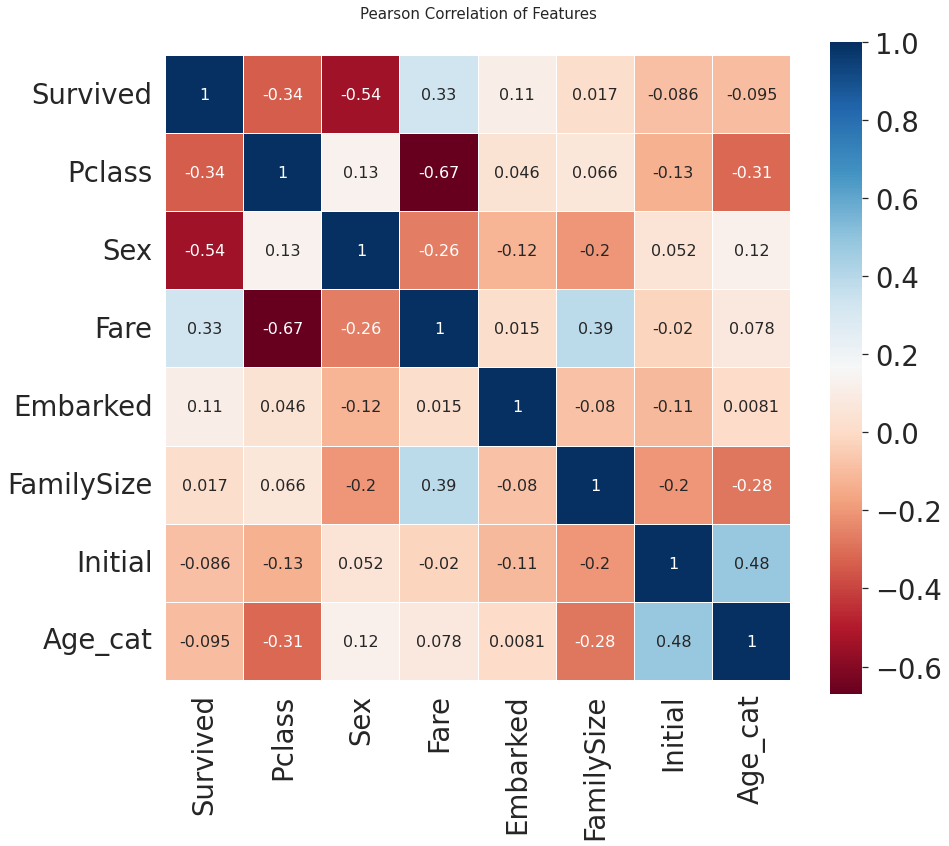

In [21]:
heatmap_data = df_train[['Survived', 'Pclass', 'Sex', 'Fare', 'Embarked', 'FamilySize', 'Initial', 'Age_cat']] # 각 feature의 Pearson correlation을 구해 heatmap으로 시가화함.

colormap = plt.cm.RdBu
plt.figure(figsize=(14, 12))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.heatmap(heatmap_data.astype(float).corr(), linewidths=0.1, vmax=1.0,
           square=True, cmap=colormap, linecolor='white', annot=True, annot_kws={"size": 16})

del heatmap_data

## 3.4 One-hot encoding on Initial and Embarked

In [22]:
df_train = pd.get_dummies(df_train, columns=['Initial'], prefix='Initial') # Initial column을 one-hot encoding 시킴
df_test = pd.get_dummies(df_test, columns=['Initial'], prefix='Initial')

In [23]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Age_cat,Initial_0,Initial_1,Initial_2,Initial_3,Initial_4
0,1,0,3,"Braund, Mr. Owen Harris",1,1,0,A/5 21171,1.981001,NaN,0,2,2,0,0,1,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,1,0,PC 17599,4.266662,C85,1,2,3,0,0,0,1,0
2,3,1,3,"Heikkinen, Miss. Laina",0,0,0,STON/O2. 3101282,2.070022,NaN,0,1,2,0,1,0,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,1,0,113803,3.972177,C123,0,2,3,0,0,0,1,0
4,5,0,3,"Allen, Mr. William Henry",1,0,0,373450,2.085672,NaN,0,1,3,0,0,1,0,0


In [24]:
df_train = pd.get_dummies(df_train, columns=['Embarked'], prefix='Embarked') # Embarked column을 one-hot encoding 시킴
df_test = pd.get_dummies(df_test, columns=['Embarked'], prefix='Embarked')

## 3.5 Drop columns

In [25]:
df_train.drop(['PassengerId', 'Name', 'SibSp', 'Parch', 'Ticket', 'Cabin'], axis=1, inplace=True) # 우리가 쓰지 않기로 한 column과 이미 다른 column으로 변형한 것들을 지워줌
df_test.drop(['PassengerId', 'Name',  'SibSp', 'Parch', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [26]:
df_train.head()

,Survived,Pclass,Sex,Fare,FamilySize,Age_cat,Initial_0,Initial_1,Initial_2,Initial_3,Initial_4,Embarked_0,Embarked_1,Embarked_2
0,0,3,1,1.981001,2,2,0,0,1,0,0,1,0,0
1,1,1,0,4.266662,2,3,0,0,0,1,0,0,1,0
2,1,3,0,2.070022,1,2,0,1,0,0,0,1,0,0
3,1,1,0,3.972177,2,3,0,0,0,1,0,1,0,0
4,0,3,1,2.085672,1,3,0,0,1,0,0,1,0,0


In [27]:
df_test.head()

,Pclass,Sex,Fare,FamilySize,Age_cat,Initial_0,Initial_1,Initial_2,Initial_3,Initial_4,Embarked_0,Embarked_1,Embarked_2
0,3,1,2.057860,1,3,0,0,1,0,0,0,0,1
1,3,0,1.945910,2,4,0,0,0,1,0,1,0,0
2,2,1,2.270836,1,6,0,0,1,0,0,0,0,1
3,3,1,2.159003,1,2,0,0,1,0,0,1,0,0
4,3,0,2.508582,3,2,0,0,0,1,0,1,0,0


# 4 Building machine learning model and prediction using the trained model

In [37]:
#importing all the required ML packages
from sklearn.ensemble import RandomForestClassifier # 유명한 randomforestclassfier 입니다. 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn import metrics # 모델의 평가를 위해서 씁니다
from sklearn.model_selection import train_test_split # traning set을 쉽게 나눠주는 함수입니다.

## 4.1 Preparation - Split dataset into train, valid, test set

In [29]:
X_train = df_train.drop('Survived', axis=1).values # target label과 예측할 때 사용하는 feature들을 구분 함.
target_label = df_train['Survived'].values
X_test = df_test.values

In [30]:
X_tr, X_vld, y_tr, y_vld = train_test_split(X_train, target_label, test_size=0.3, random_state=2018) # validation set과 train set을 구분함.

## 4.2 Model generation and prediction

### Random forest

In [31]:
model = RandomForestClassifier() # 랜덤 포레스트를 사용하여 학습하고 예측함.
model.fit(X_tr, y_tr)
prediction = model.predict(X_vld)

In [32]:
print('총 {}명 중 {:.2f}% 정확도로 생존을 맞춤'.format(y_vld.shape[0], 100 * metrics.accuracy_score(prediction, y_vld)))

총 268명 중 82.84% 정확도로 생존을 맞춤


### Logistic regression

In [35]:
model_LoRe = LogisticRegression() # 로지스틱 리그레션를 사용하여 학습하고 예측함.
model_LoRe.fit(X_tr, y_tr)
prediction_LoRe = model_LoRe.predict(X_vld)

In [36]:
print('총 {}명 중 {:.2f}% 정확도로 생존을 맞춤'.format(y_vld.shape[0], 100 * metrics.accuracy_score(prediction_LoRe, y_vld)))

총 268명 중 87.31% 정확도로 생존을 맞춤


### SVC

In [38]:
model_SVC = LinearSVC(C=0.1, max_iter=100000) # SVC를 사용하여 학습하고 예측함.
model_SVC.fit(X_tr, y_tr)
prediction_SVC = model_SVC.predict(X_vld)

In [39]:
print('총 {}명 중 {:.2f}% 정확도로 생존을 맞춤'.format(y_vld.shape[0], 100 * metrics.accuracy_score(prediction_SVC, y_vld)))

총 268명 중 86.57% 정확도로 생존을 맞춤


## 4.3 Feature importance 

In [34]:
from pandas import Series # 학습한 모델에 사용한 feature들의 importance를 분석함.

feature_importance = model.feature_importances_
Series_feat_imp = Series(feature_importance, index=df_test.columns)

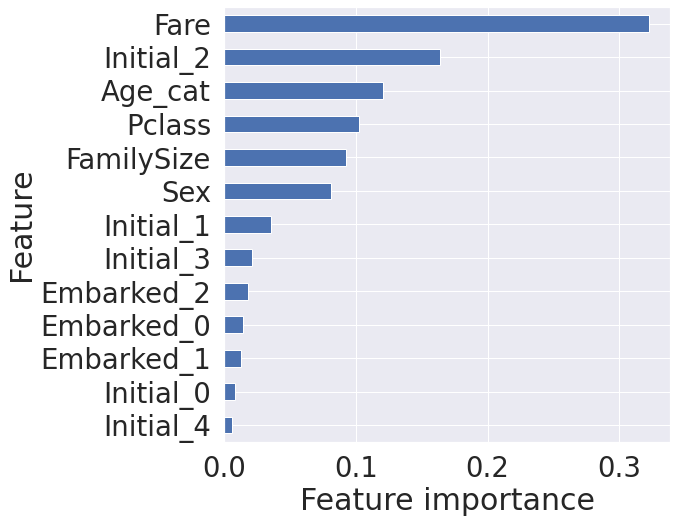

In [35]:
plt.figure(figsize=(8, 8)) # feature importance를 분석한 결과를 sorting하여 그래프로 그려봄
Series_feat_imp.sort_values(ascending=True).plot.barh()
plt.xlabel('Feature importance')
plt.ylabel('Feature')
plt.show()

## 4.4 Prediction on Test set 

In [40]:
submission = pd.read_csv(data_dir+'gender_submission.csv')

In [41]:
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [42]:
prediction = model.predict(X_test)
submission['Survived'] = prediction

In [43]:
submission.to_csv('./my_first_submission.csv', index=False)